**1. Import Libraries**

In [1]:
import pandas as pd
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from autogluon.tabular import TabularPredictor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor,ExtraTreesRegressor,GradientBoostingRegressor,AdaBoostRegressor)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
pd.set_option('display.max_columns', None)


c:\Users\BalajiChitrarasu\autogluon_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**2. Upload the Dataset**

In [2]:
dataset= pd.read_csv("dataset/cargo_breakdown_dataset_30000.csv")
dataset


,Unnamed: 0,Flight_Number,Arrival_Date,Year,Month,Season,Origin,Destination,Flight_Type,Aircraft_Type,Shipment_Count,Cargo_Weight_KG,Cargo_Volume_CBM,ULD_Count,ULD_Type,Pallet_Count,Nature_of_Goods,Cargo_Mix_Complexity,Manpower_Assigned,Forklift_Count,Equipment_Availability,Shift,Weather_Condition,Customs_Hold_Units,Storage_Distance_Meters,Breakdown_Priority,Breakdown_Time_Minutes
0,0,SV3473,2023-08-17,2023,8,Normal,Medina,Jeddah,Domestic,A320,112,4157,27,2,PLA,7,Pharma,Low,19,2,Medium,Night,Clear,13,35,Critical,67
1,1,SV6195,2024-07-23,2024,7,Hajj,Dammam,Jeddah,Domestic,A320,228,7424,53,5,AKE,23,Perishable,Medium,6,4,Medium,Night,Foggy,10,67,Critical,154
2,2,QR4375,2023-09-13,2023,9,Normal,Doha,Jeddah,International,B747F,800,38700,495,16,PAG,5,E-Commerce,Medium,4,1,Medium,Evening,Foggy,7,60,Urgent,258
3,3,QR9372,2024-03-05,2024,3,Ramadan,Doha,Jeddah,International,B747F,1150,26215,473,33,PAG,12,General Cargo,Medium,9,3,Medium,Morning,Clear,14,158,Normal,300
4,4,AI5503,2024-03-08,2024,3,Ramadan,Mumbai,Jeddah,International,B777F,905,45071,273,18,AKE,24,Dangerous Goods,Low,6,4,Low,Morning,Rainy,8,239,Critical,272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29995,SV570,2024-07-17,2024,7,Hajj,Medina,Jeddah,Domestic,A320,206,10711,90,2,PAG,4,General Cargo,High,11,3,Low,Night,Rainy,4,106,Urgent,116
29996,29996,TK7457,2024-01-29,2024,1,Normal,Istanbul,Jeddah,International,A350,395,6815,274,5,AKE,21,Pharma,Low,4,1,Medium,Morning,Rainy,12,206,Urgent,162
29997,29997,MS3358,2023-05-21,2023,5,Normal,Cairo,Jeddah,International,A350,161,8807,150,9,PAG,0,E-Commerce,Medium,5,8,Low,Night,Clear,2,218,Critical,84
29998,29998,SV929,2023-03-04,2023,3,Ramadan,Medina,Jeddah,Domestic,A320,61,9899,61,5,PLA,16,Dangerous Goods,Low,2,7,Medium,Night,Rainy,0,262,Urgent,127


**3. Build the model using Autogluon**

In [4]:
# Remove unwanted columns
drop_cols = [
    "Unnamed: 0",
    "Flight_Number",
    "Arrival_Date",
]

df = dataset.drop(columns=drop_cols)

# Target Column
target = "Breakdown_Time_Minutes"

# Train-Test Split
train_data = df.sample(frac=0.8, random_state=42)
test_data = df.drop(train_data.index)

print("Train Shape :", train_data.shape)
print("Test Shape :", test_data.shape)

# AutoGluon Training
predictor = TabularPredictor(
    label=target,
    problem_type="regression",
    eval_metric="r2"
).fit(
    train_data=train_data,
    presets="best_quality",
    time_limit=1000
)

# Predictions
y_pred = predictor.predict(test_data)

# Actual Values
y_true = test_data[target]

# Metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print("\nModel Performance")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

# Leaderboard
print("\nLeaderboard")
print(
    predictor.leaderboard(
        test_data,
        silent=True
    )
)

# Feature Importance
print("\nFeature Importance")
print(
    predictor.feature_importance(
        test_data
    )
)

# Save Model
predictor.save()

print("Model Saved Successfully")

No path specified. Models will be saved in: "AutogluonModels\ag-20260618_062203"


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          12
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       15.22 GB / 31.69 GB (48.0%)
Disk Space Avail:   365.44 GB / 475.95 GB (76.8%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluo

Train Shape : (24000, 24)
Test Shape : (6000, 24)


(_dystack pid=31776) 	0.9103	 = Validation score   (r2)
(_dystack pid=31776) 	16.36s	 = Training   runtime
(_dystack pid=31776) 	1.93s	 = Validation runtime
(_dystack pid=31776) Fitting model: CatBoost_BAG_L1 ... Training model for up to 128.64s of the 262.24s of remaining time.
(_dystack pid=31776) 	Fitting 8 child models (S1F1 - S1F8) | Fitting with ParallelLocalFoldFittingStrategy (8 workers, per: cpus=1, gpus=0, memory=2.67%)
(_dystack pid=34436) Running DyStack sub-fit ...
(_dystack pid=34436) Beginning AutoGluon training ... Time limit = 250s
(_dystack pid=34436) AutoGluon will save models to "c:\Users\BalajiChitrarasu\Desktop\TASK_10\AutogluonModels\ag-20260618_062203\ds_sub_fit\sub_fit_ho"
(_dystack pid=34436) Train Data Rows:    21333
(_dystack pid=34436) Train Data Columns: 23
(_dystack pid=34436) Label Column:       Breakdown_Time_Minutes
(_dystack pid=34436) Problem Type:       regression
(_dystack pid=34436) Preprocessing data ...
(_dystack pid=34436) Using Feature Generat

(autoscaler +3m56s) Tip: use `ray status` to view detailed cluster status. To disable these messages, set RAY_SCHEDULER_EVENTS=0.
(autoscaler +3m56s) Warning: The following resource request cannot be scheduled right now: {'CPU': 1.0}. This is likely due to all cluster resources being claimed by actors. Consider creating fewer actors or adding more nodes to this Ray cluster.
(_ray_fit pid=18232) [1000]	valid_set's l2: 83.5018	valid_set's r2: 0.978372
(autoscaler +4m32s) Warning: The following resource request cannot be scheduled right now: {'CPU': 1.0}. This is likely due to all cluster resources being claimed by actors. Consider creating fewer actors or adding more nodes to this Ray cluster.
(_ray_fit pid=18232) [2000]	valid_set's l2: 83.1846	valid_set's r2: 0.978455 [repeated 4x across cluster]
(_ray_fit pid=31952) [1000]	valid_set's l2: 82.3076	valid_set's r2: 0.978802
(_ray_fit pid=8356) [1000]	valid_set's l2: 82.7267	valid_set's r2: 0.97832
(_ray_fit pid=8356) [2000]	valid_set's l2

...

                    model  score_test  score_val eval_metric  pred_time_test  \
0     WeightedEnsemble_L3    0.982111   0.980024          r2        2.691744   
1         CatBoost_BAG_L2    0.982050   0.979891          r2        1.919982   
2         LightGBM_BAG_L2    0.981918   0.979728          r2        2.003937   
3       LightGBMXT_BAG_L2    0.981620   0.979106          r2        2.357589   
4  RandomForestMSE_BAG_L2    0.980983   0.978879          r2        2.761785   
5       LightGBMXT_BAG_L1    0.980587   0.978799          r2        1.798383   
6     WeightedEnsemble_L2    0.980587   0.978799          r2        1.806390   

   pred_time_val    fit_time  pred_time_test_marginal  pred_time_val_marginal  \
0       9.447681  140.020292                 0.007003                0.000995   
1       6.442640  102.281428                 0.121598                0.122317   
2       6.567058   27.186355                 0.205553                0.246736   
3       9.077633   47.256448       

	294.57s	= Expected runtime (58.91s per shuffle set)
	176.45s	= Actual runtime (Completed 5 of 5 shuffle sets)


                         importance    stddev       p_value  n  p99_high  \
Customs_Hold_Units         0.167812  0.003336  1.872491e-08  5  0.174680   
ULD_Count                  0.132301  0.001163  7.174973e-10  5  0.134696   
Cargo_Weight_KG            0.086567  0.001485  1.039314e-08  5  0.089625   
Manpower_Assigned          0.058316  0.001093  1.482281e-08  5  0.060567   
Aircraft_Type              0.052263  0.001138  2.700605e-08  5  0.054607   
Season                     0.051897  0.001034  1.887648e-08  5  0.054026   
Equipment_Availability     0.040147  0.000590  5.579432e-09  5  0.041361   
Shipment_Count             0.037348  0.000621  9.164771e-09  5  0.038627   
Cargo_Volume_CBM           0.034159  0.000499  5.456703e-09  5  0.035187   
Nature_of_Goods            0.032919  0.000589  1.228735e-08  5  0.034131   
Breakdown_Priority         0.031779  0.000649  2.092547e-08  5  0.033116   
Cargo_Mix_Complexity       0.031582  0.000403  3.169524e-09  5  0.032411   
Flight_Type 

TabularPredictor saved. To load, use: predictor = TabularPredictor.load("c:\Users\BalajiChitrarasu\Desktop\TASK_10\AutogluonModels\ag-20260618_062203")


Model Saved Successfully


**4. EDA**

4.1 Target Distribution

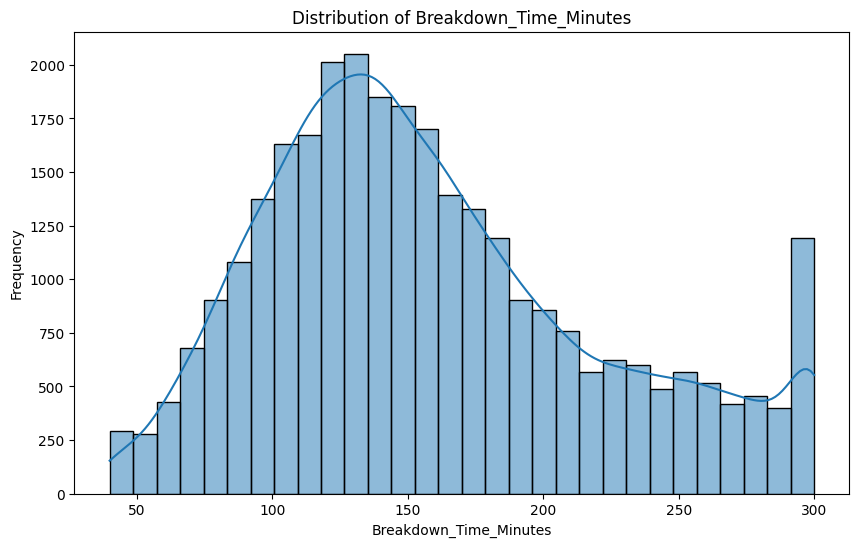

In [ ]:
target_column = "Breakdown_Time_Minutes"

plt.figure(figsize=(10,6))

sns.histplot(
    dataset[target_column],
    bins=30,
    kde=True
)

plt.title(
    f"Distribution of {target_column}"
)

plt.xlabel(target_column)
plt.ylabel("Frequency")

plt.show()

4.1.2 Handling Sweked for Target Value 

In [ ]:
# Original Target
target = dataset["Breakdown_Time_Minutes"]

# Before Skewness
before_skew = target.skew()

# Log Transformation
target_log = np.log1p(target)

# After Skewness
after_skew = target_log.skew()

# Comparison Table
skew_df = pd.DataFrame({
    "Target": ["Breakdown_Time_Minutes"],
    "Before_Transformation": [before_skew],
    "After_Log1p_Transformation": [after_skew]
})

print(skew_df)

                   Target  Before_Transformation  After_Log1p_Transformation
0  Breakdown_Time_Minutes               0.586428                   -0.337572


4.2 Numerical Columns Distribution

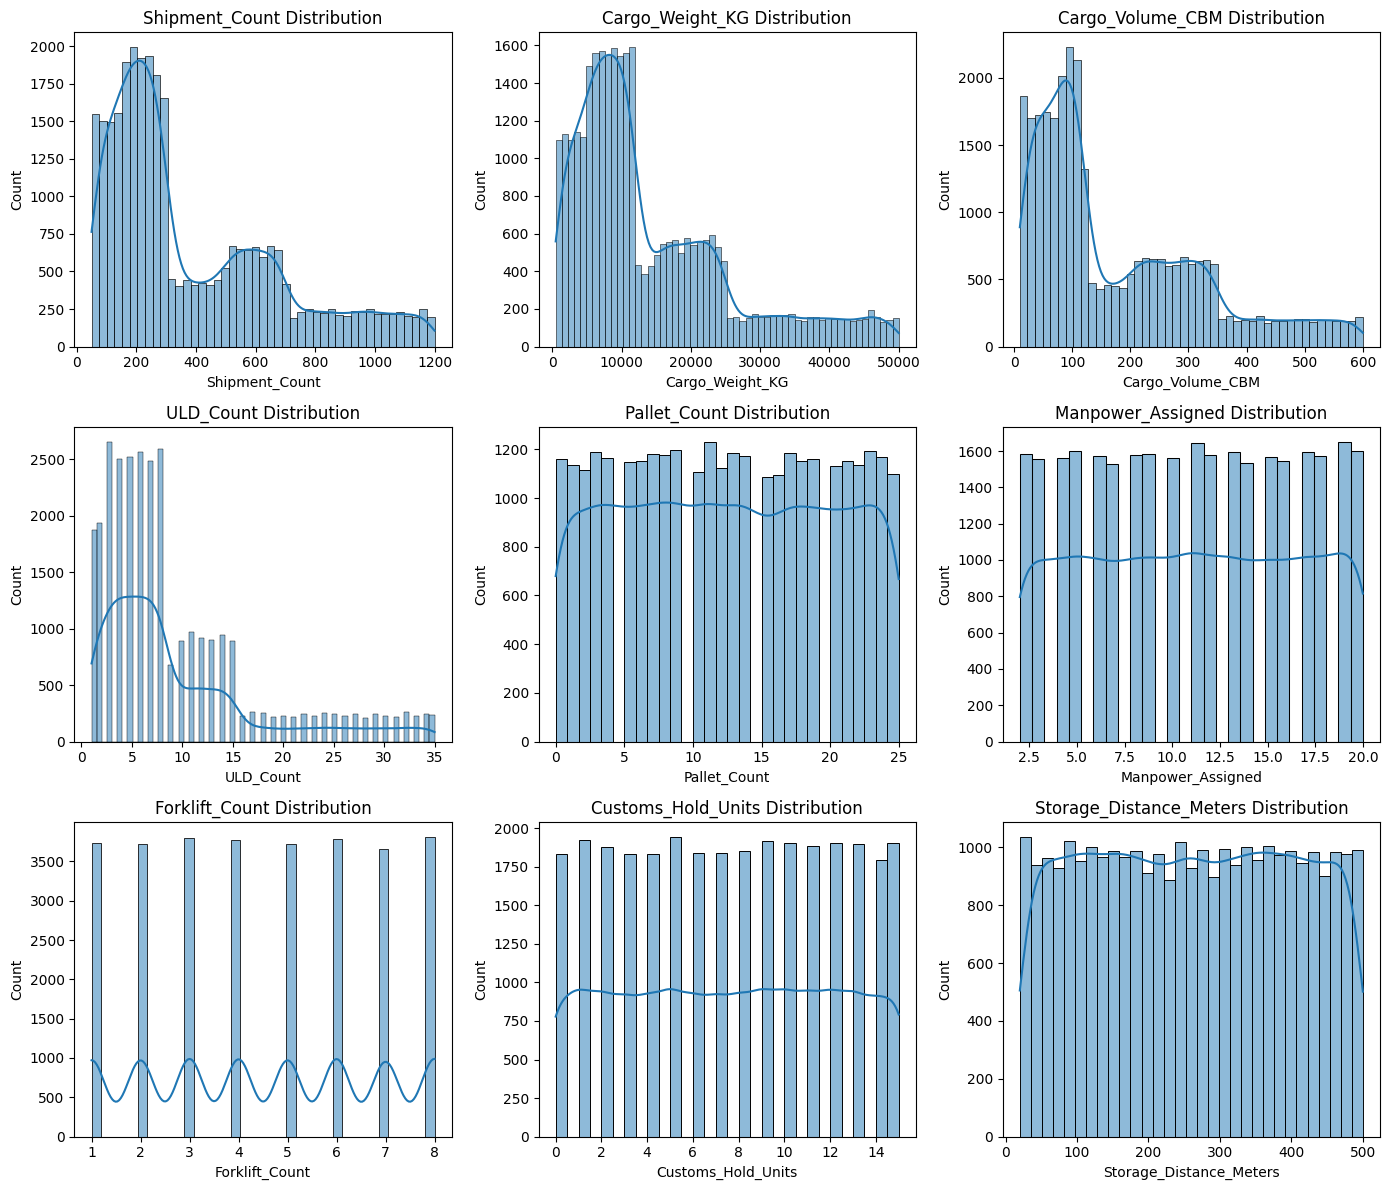

In [ ]:
features = [
    "Shipment_Count",
    "Cargo_Weight_KG",
    "Cargo_Volume_CBM",
    "ULD_Count",
    "Pallet_Count",
    "Manpower_Assigned",
    "Forklift_Count",
    "Customs_Hold_Units",
    "Storage_Distance_Meters"
]
n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, n_rows * 4)
)
axes = axes.flatten()
for i, feature in enumerate(features):
    sns.histplot(
        data=dataset,
        x=feature,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(
        f"{feature} Distribution"
    )
for j in range(
    len(features),
    len(axes)
):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

4.2.1 check skewed value

In [ ]:
# Numerical Columns
numerical_cols = dataset.select_dtypes(
    include=['int64', 'float64']
).columns

# Skewness Values
skewness_df = pd.DataFrame({
    "Feature": numerical_cols,
    "Skewness": dataset[numerical_cols].skew()
})

skewness_df = skewness_df.sort_values(
    by="Skewness",
    ascending=False
)

skewness_df = pd.DataFrame({
    "Feature": numerical_cols,
    "Skewness": dataset[numerical_cols].skew()
})

skewness_df["Distribution"] = skewness_df["Skewness"].apply(
    lambda x:
    "Highly Positively Skewed" if x > 1
    else "Moderately Positively Skewed" if x > 0.5
    else "Approximately Normal" if -0.5 <= x <= 0.5
    else "Moderately Negatively Skewed" if x >= -1
    else "Highly Negatively Skewed"
)

skewness_df.sort_values(
    by="Skewness",
    ascending=False,
    inplace=True
)

display(skewness_df)

,Feature,Skewness,Distribution
ULD_Count,ULD_Count,1.495385,Highly Positively Skewed
Cargo_Weight_KG,Cargo_Weight_KG,1.279633,Highly Positively Skewed
Shipment_Count,Shipment_Count,1.043110,Highly Positively Skewed
Cargo_Volume_CBM,Cargo_Volume_CBM,1.042753,Highly Positively Skewed
Breakdown_Time_Minutes,Breakdown_Time_Minutes,0.586428,Moderately Positively Skewed
Pallet_Count,Pallet_Count,0.007779,Approximately Normal
Forklift_Count,Forklift_Count,0.003622,Approximately Normal
Month,Month,0.001336,Approximately Normal
Storage_Distance_Meters,Storage_Distance_Meters,0.001238,Approximately Normal
Unnamed: 0,Unnamed: 0,0.000000,Approximately Normal


4.2.2 Handle the sweked data

In [ ]:
df_skew = dataset.copy()

skew_cols = [
    "ULD_Count",
    "Cargo_Weight_KG",
    "Shipment_Count",
    "Cargo_Volume_CBM"
]

for col in skew_cols:
    df_skew[col] = np.log1p(df_skew[col])
print("Skewness handled successfully")
before_skew = dataset[skew_cols].skew()
after_skew = df_skew[skew_cols].skew()
comparison = pd.DataFrame({
    "Before": before_skew,
    "After": after_skew
})
print(comparison)

Skewness handled successfully
                    Before     After
ULD_Count         1.495385  0.080520
Cargo_Weight_KG   1.279633 -0.592546
Shipment_Count    1.043110 -0.093429
Cargo_Volume_CBM  1.042753 -0.348920


4.3 Categorical Columns Distribution


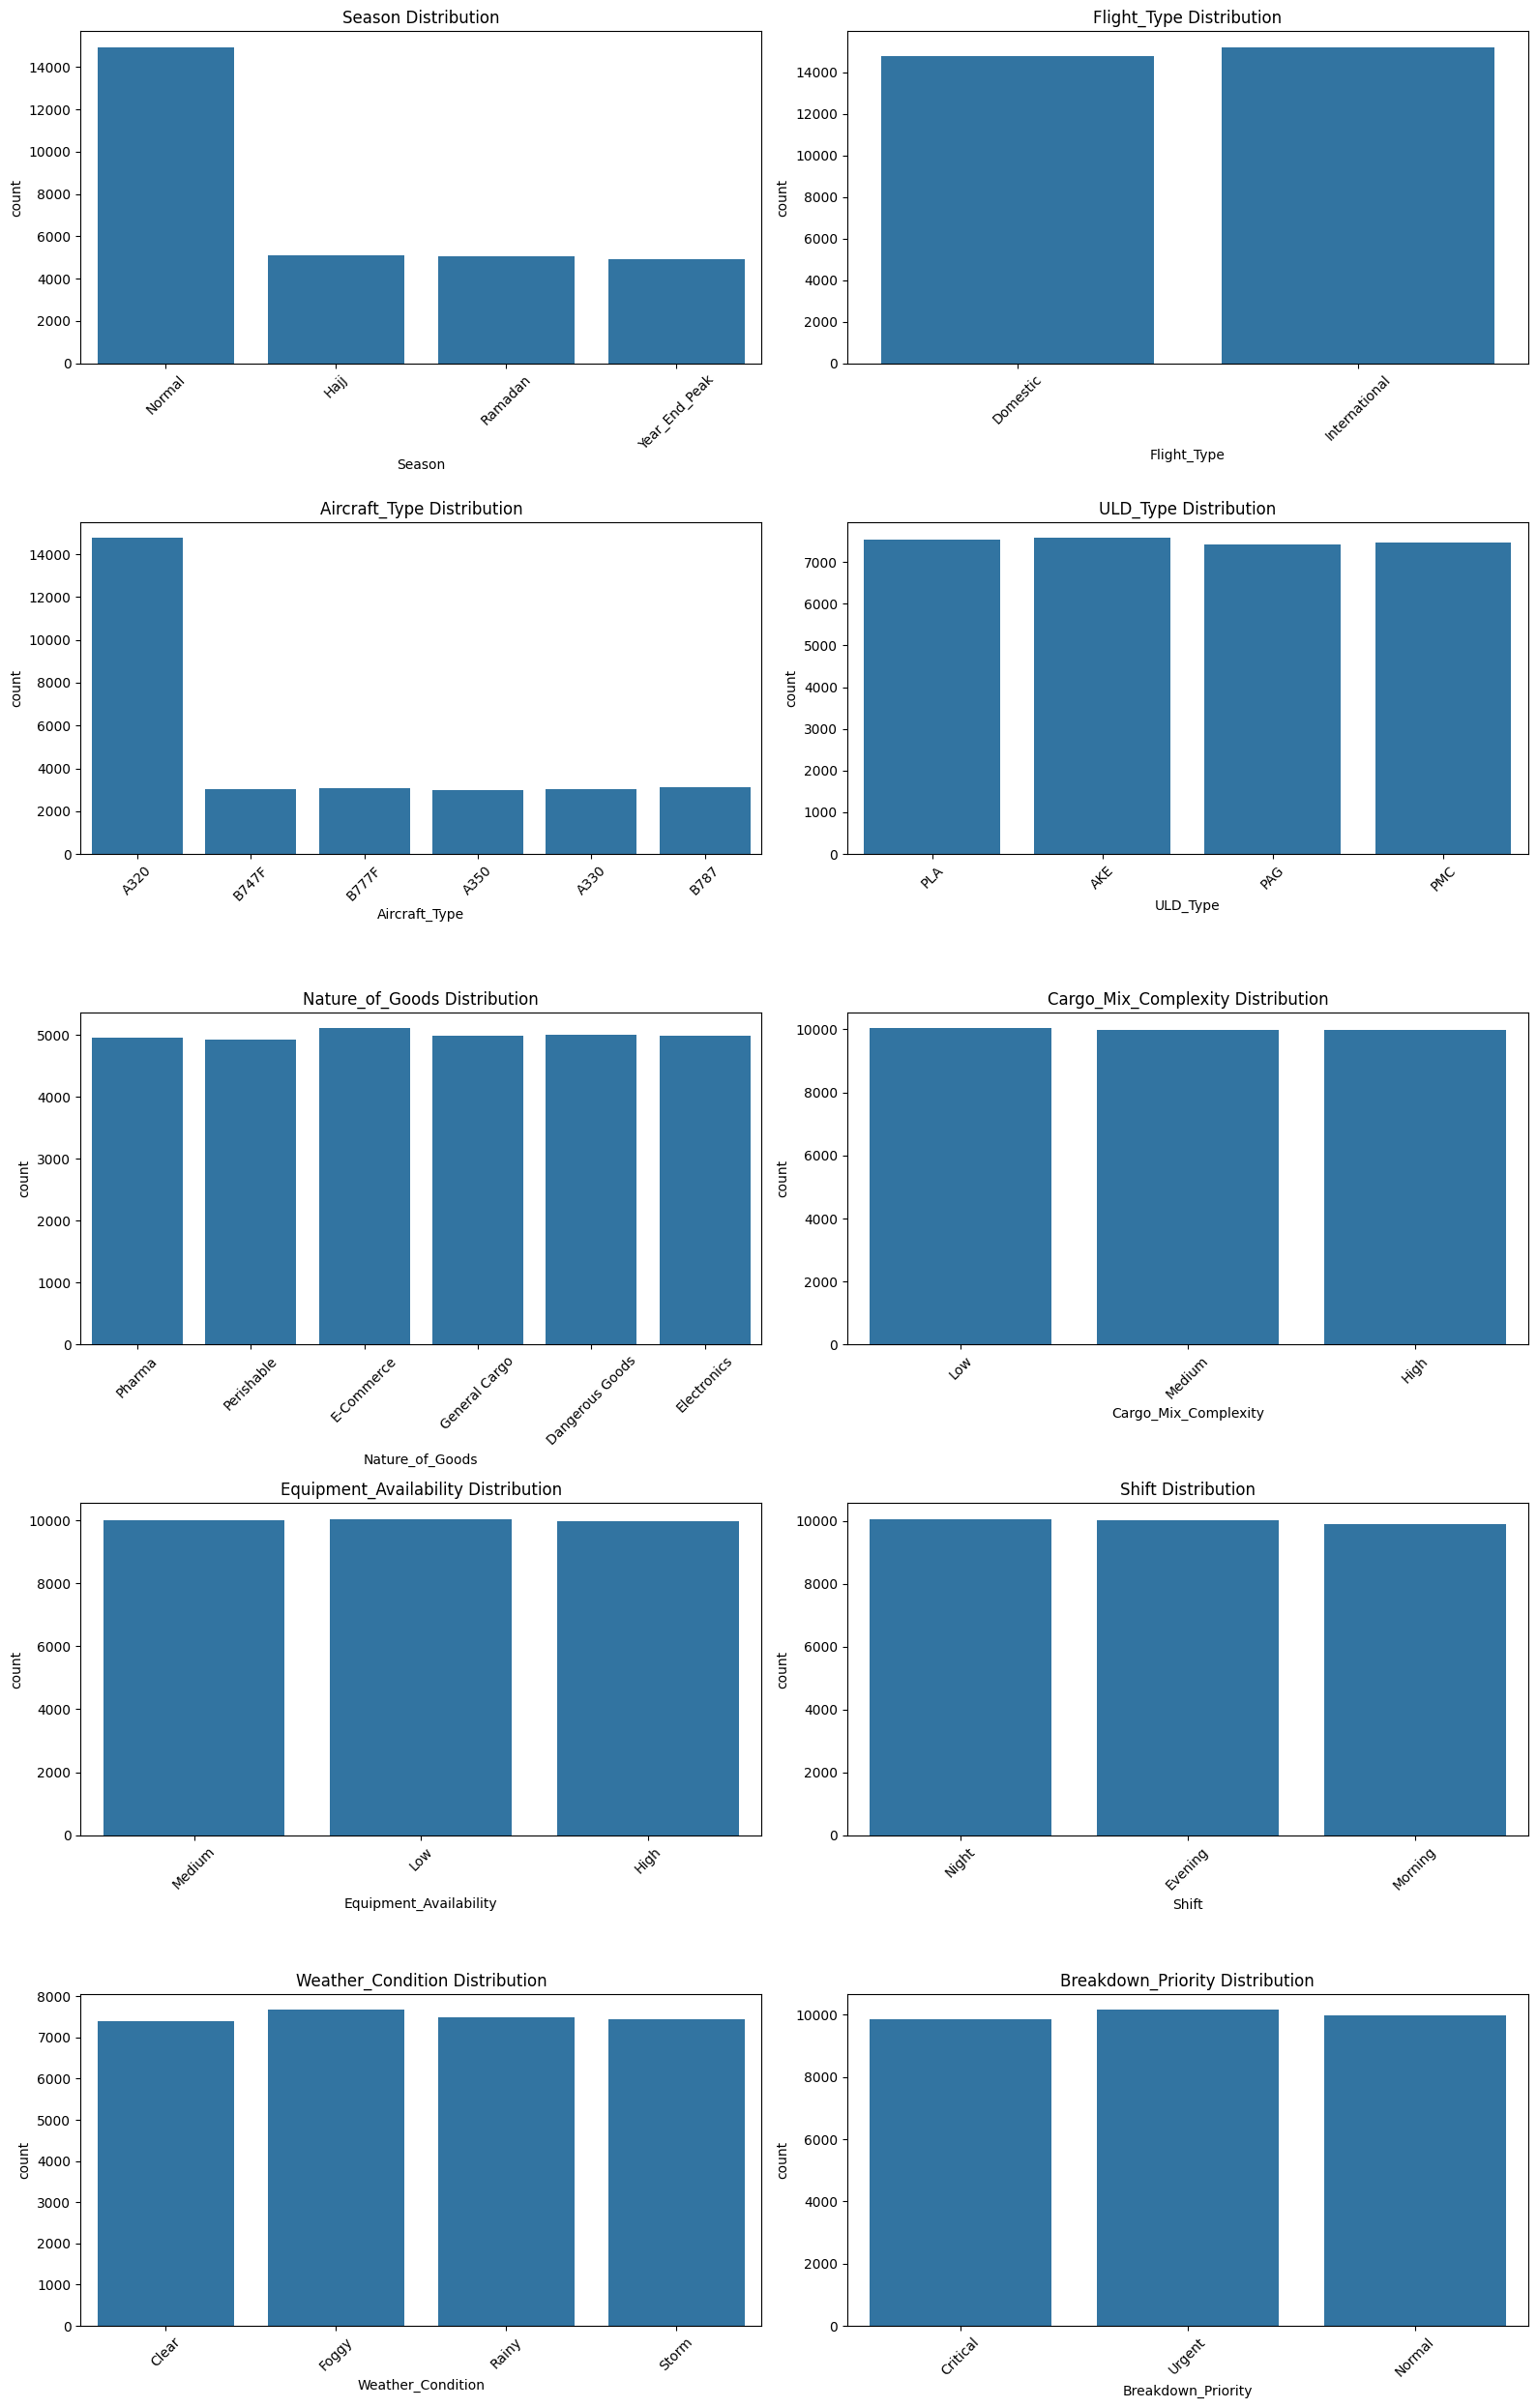

In [ ]:
categorical_cols = [
    "Season",
    "Flight_Type",
    "Aircraft_Type",
    "ULD_Type",
    "Nature_of_Goods",
    "Cargo_Mix_Complexity",
    "Equipment_Availability",
    "Shift",
    "Weather_Condition",
    "Breakdown_Priority"
]

n_cols = 2
n_rows = (len(categorical_cols) + 1) // 2
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, n_rows * 5)
)
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    sns.countplot(
        data=dataset,
        x=col,
        ax=axes[i]
    )
    axes[i].set_title(
        f"{col} Distribution"
    )
    axes[i].tick_params(
        axis='x',
        rotation=45
    )
for j in range(
    len(categorical_cols),
    len(axes)
):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

**5. Feature Engineering**

5.1 Data Splitting

In [ ]:
# Target Column
TARGET = "Breakdown_Time_Minutes"

# Columns not used for training
drop_columns = [
    "Breakdown_Time_Minutes",
    "Arrival_Date",
    "Flight_Number"
]

# Features (X)
X = dataset.drop(
    columns=drop_columns,
    axis=1
)

# Target (y)
y = dataset[TARGET]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

# Train 70%
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)


# Validation 15%
# Test 15%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

X_train_cat=X_train.copy()
y_train_cat=y_train.copy()
X_val_cat=X_val.copy()
y_val_cat=y_val.copy()
X_test_cat=X_test.copy()
y_test_cat=y_test.copy()

X Shape: (30000, 24)
y Shape: (30000,)

Features:
['Unnamed: 0', 'Year', 'Month', 'Season', 'Origin', 'Destination', 'Flight_Type', 'Aircraft_Type', 'Shipment_Count', 'Cargo_Weight_KG', 'Cargo_Volume_CBM', 'ULD_Count', 'ULD_Type', 'Pallet_Count', 'Nature_of_Goods', 'Cargo_Mix_Complexity', 'Manpower_Assigned', 'Forklift_Count', 'Equipment_Availability', 'Shift', 'Weather_Condition', 'Customs_Hold_Units', 'Storage_Distance_Meters', 'Breakdown_Priority']


5.2 Encoding for Categorical Columns

In [ ]:
categorical_cols = X_train.select_dtypes(
    include="object"
).columns

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(
        X_train[col]
    )
    X_val[col]=le.transform(
        X_val[col]
        )
    X_test[col] = le.transform(
        X_test[col]
    )
    label_encoders[col] = le

print("Encoding Completed")

Encoding Completed


5.3 Scaling for Numerical Columns

In [ ]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled=X_val.copy()
X_test_scaled = X_test.copy()


X_train_scaled[X_train.columns] = scaler.fit_transform(
    X_train
)
X_val_scaled[X_val.columns] = scaler.transform(
    X_val
)

X_test_scaled[X_test.columns] = scaler.transform(
    X_test
)

print("Scaling Completed")

Scaling Completed


**6. Model Building**

6.1 Linear Regression

In [ ]:
# Initialize Model
lr_model = LinearRegression()
lr_model.fit(
    X_train_scaled,
    y_train
)

y_pred_lr = lr_model.predict(
    X_val_scaled
)

# MAE
lr_mae = mean_absolute_error(y_val, y_pred_lr)

# MSE
lr_mse = mean_squared_error(y_val, y_pred_lr)

# RMSE
lr_rmse = np.sqrt(lr_mse)

# R2
lr_r2 = r2_score(y_val, y_pred_lr)

print("MAE :", lr_mae)
print("MSE :", lr_mse)
print("RMSE :", lr_rmse)
print("R2 Score :", lr_r2)

MAE : 16.42258905583811
MSE : 412.46929717276464
RMSE : 20.30934014616833
R2 Score : 0.8925514397585161


6.2 Decision Tree Regressor

In [ ]:
# dt_param_grid = {
#     'max_depth': [5, 10, 15, 20],
#     'min_samples_split': [2, 5, 4,10],
#     'min_samples_leaf': [1, 2, 4, 5],
#     'max_features': ['sqrt', 'log2',None]
# }

# dt_grid = GridSearchCV(
#     estimator=DecisionTreeRegressor(
#         random_state=42
#     ),
#     param_grid=dt_param_grid,
#     cv=5,
#     scoring='neg_mean_squared_error',
#     n_jobs=-1,
#     verbose=1
# )

# dt_grid.fit(
#     X_train,
#     y_train
# )

# print("Best Parameters:")
# print(dt_grid.best_params_)

# print("\nBest Score:")
# print(dt_grid.best_score_)

Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best Parameters:
{'max_depth': 10, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 2}

Best Score:
-708.9377130878887


In [ ]:
dt_model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=5,
    max_features=None,
    random_state=42
)
dt_model.fit(
    X_train,
    y_train
)
y_pred_dt = dt_model.predict(
    X_val
)


dt_mae = mean_absolute_error(
    y_val,
    y_pred_dt
)
dt_mse = mean_squared_error(
    y_val,
    y_pred_dt
)
dt_rmse = np.sqrt(
    dt_mse
)
dt_r2 = r2_score(
    y_val,
    y_pred_dt
)

print("MAE :", dt_mae)
print("MSE :", dt_mse)
print("RMSE :", dt_rmse)
print("R2 Score :", dt_r2)


MAE : 20.709949383700238
MSE : 687.6868648144625
RMSE : 26.223784334349276
R2 Score : 0.8208570576579318


6.3 Random Forest Regressor

In [ ]:
# rf_param_grid = {
#     'n_estimators': [100, 200, 300, 500],
#     'max_depth': [5, 10, 15, 20, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': ['sqrt', 'log2']
# }

# rf_random = RandomizedSearchCV(
#     estimator=RandomForestRegressor(
#         random_state=42
#     ),
#     param_distributions=rf_param_grid,
#     n_iter=20,
#     cv=5,
#     scoring='neg_mean_squared_error',
#     verbose=1,
#     random_state=42,
#     n_jobs=-1
# )

# rf_random.fit(
#     X_train,
#     y_train
# )

# print("Best Parameters:")
# print(
#     rf_random.best_params_
# )
# print("\nBest Score:")
# print(
#     rf_random.best_score_
# )

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}

Best Score:
-368.4050794491487


In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='log2',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(
    X_val
)

rf_mae = mean_absolute_error(y_val,  y_pred_rf)
rf_mse = mean_squared_error(y_val, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_val, y_pred_rf)

print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE :", rf_rmse)
print("R2 Score :", rf_r2)

MAE : 15.085585285770051
MSE : 351.02779404840425
RMSE : 18.735735748787775
R2 Score : 0.9085569972510049


6.4 Extra Trees Regressor

6.5 XGBoost Regressor

In [ ]:
# xgb_param_grid = {
#     'n_estimators': [100, 200, 300, 500],
#     'max_depth': [3, 5, 7, 10],
#     'learning_rate': [0.01, 0.05, 0.1, 0.2],
#     'subsample': [0.8, 0.9, 1.0],
#     'colsample_bytree': [0.8, 0.9, 1.0],
#     'min_child_weight': [1, 3, 5]
# }

# xgb_random = RandomizedSearchCV(
#     estimator=XGBRegressor(
#         random_state=42
#     ),
#     param_distributions=xgb_param_grid,
#     n_iter=20,
#     cv=5,
#     scoring='neg_mean_squared_error',
#     verbose=1,
#     random_state=42,
#     n_jobs=-1
# )

# xgb_random.fit(X_train,y_train)
# print("Best Parameters:")
# print(xgb_random.best_params_)

# print("\nBest Score:")
# print(
#     xgb_random.best_score_
# )

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters:
{'subsample': 0.9, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

Best Score:
-85.3541976928711


In [ ]:
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.8,
    min_child_weight=1,
    random_state=42
)
xgb_model.fit(X_train,y_train)
y_pred_xgb = xgb_model.predict(X_val)


xgb_mae = mean_absolute_error(y_val,y_pred_xgb)
xgb_mse = mean_squared_error(y_val, y_pred_xgb)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_val,y_pred_xgb)

print("MAE :", xgb_mae)
print("MSE :", xgb_mse)
print("RMSE :", xgb_rmse)
print("R2 Score :", xgb_r2)

MAE : 7.131200313568115
MSE : 81.97616577148438
RMSE : 9.054069017380217
R2 Score : 0.9786451458930969


6.6 CatBoost Regressor

In [ ]:
cat_features = X_train_cat.select_dtypes(
    include=['object','category']
).columns.tolist()

for col in cat_features:
    X_train_cat[col] = X_train_cat[col].astype('category')
    X_val_cat[col] = X_val_cat[col].astype('category')
    X_test_cat[col] = X_test_cat[col].astype('category')

In [ ]:
# cat_param_grid = {
#     'iterations':[100,200,300,500],
#     'depth':[4,6,8,10],
#     'learning_rate':[0.01,0.05,0.1,0.2],
#     'l2_leaf_reg':[1,3,5,7,9]
# }

# cat_random = RandomizedSearchCV(
#     estimator=CatBoostRegressor(
#         random_state=42,
#         verbose=0
#     ),
#     param_distributions=cat_param_grid,
#     n_iter=20,
#     scoring='neg_mean_squared_error',
#     cv=5,
#     random_state=42,
#     n_jobs=-1
# )

# cat_random.fit(X_train_cat, y_train_cat,cat_features=cat_features)
# print("Best Parameters:")
# print(cat_random.best_params_)

# print("\nBest Score:")
# print(cat_random.best_score_)

Best Parameters:
{'learning_rate': 0.1, 'l2_leaf_reg': 5, 'iterations': 500, 'depth': 8}

Best Score:
-74.06290329019174


In [ ]:
cat_model = CatBoostRegressor(
    iterations=500,
    depth=8,
    learning_rate=0.01,
    l2_leaf_reg=5,
    random_state=42,
    verbose=0
)
cat_model.fit(X_train_cat,y_train_cat,cat_features=cat_features)
y_pred_cat = cat_model.predict(X_val_cat)

cat_mae = mean_absolute_error(y_val_cat, y_pred_cat)
cat_mse = mean_squared_error(y_val_cat, y_pred_cat)
cat_rmse = np.sqrt(cat_mse)
cat_r2 = r2_score(y_val_cat, y_pred_cat)

print("MAE :", cat_mae)
print("MSE :", cat_mse)
print("RMSE :", cat_rmse)
print("R2 Score :", cat_r2)


MAE : 10.366847263619524
MSE : 170.19993555426004
RMSE : 13.046069735911273
R2 Score : 0.955662789560701


**7. Model Comparision**

In [ ]:
results = []

results.append(["Linear Regression", lr_r2,lr_mae])
results.append(["Decision Tree", dt_r2,dt_mae])
results.append(["Random Forest", rf_r2,rf_mae])
results.append(["XGBoost", xgb_r2, xgb_mae])
results.append(["CatBoost", cat_r2, cat_mae])
results.append(["AutoGluon",0.9821,6.58])

comparison_df = pd.DataFrame(
    results,
    columns=["Model", "R2","MAE"]
)
comparison_df = comparison_df.sort_values(
    by="R2",
    ascending=False
)
print(comparison_df)

               Model        R2        MAE
5          AutoGluon  0.983500   6.330000
3            XGBoost  0.978645   7.131200
4           CatBoost  0.955663  10.366847
2      Random Forest  0.908557  15.085585
0  Linear Regression  0.892551  16.422589
1      Decision Tree  0.820857  20.709949


**8. Feature Importance**

In [ ]:
feature_importance = predictor.feature_importance(test_data)
feature_importance

NameError: name 'predictor' is not defined

In [ ]:
feature_importance.reset_index(inplace=True)
feature_importance.head(15)

NameError: name 'feature_importance' is not defined

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(15),
    x="importance",
    y="index"
)
plt.title("Top 15 Important Features")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.show()

NameError: name 'feature_importance' is not defined

<Figure size 1000x600 with 0 Axes>